In [1]:
import torch
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
import torchvision.transforms as transforms
from collections import Counter
import numpy as np
import random
import warnings
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
from torchvision.datasets import ImageFolder

In [2]:
pip install torch-lr-finder

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 27.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 21.0 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.8.93
    Uninstalling nvidia-nvjitlink-cu12-12.8.93:
      Successfully uninstalled nvidia-nvjitlink-cu12-12.8.93
  Attempting uninstall: nvidia-curand-cu12
    Found existing installation: nvidia-curand-cu12 10.3.9.90
    Uninstalling nvidia-curand-cu12-10.3.9.90:
      Successfully uninstalled nvidia-curand-cu12-10.3.9.90
  Attemptin

In [3]:
# set up python environment
seedVal = 123
random.seed(seedVal)
np.random.seed(seedVal)
torch.manual_seed(seedVal)
warnings.filterwarnings('ignore')

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.cuda.manual_seed(seedVal)
torch.cuda.manual_seed_all(seedVal)

In [4]:
def worker_init_fn(worker_id):
    seed = seedVal + worker_id
    np.random.seed(seed)
    random.seed(seed)

In [5]:
# define the transform to normalize, resize the images
transform = transforms.Compose([
    #Resizes the shortest side to 224 pixels.
    #This could potentialy make smaller images bigger and bigger images smaller.
    transforms.Resize(224), #If both sides are resized with the same length it could potentially distort the image.
    transforms.CenterCrop(224), ##Takes a sample of every image by cropping the center of the image and obtaining a 224x224 pixel image
    transforms.ToTensor(), #Convert images to tensor (To fit images into the model)
    transforms.Normalize(mean = [0.485, 0.456, 0.406], std = [0.229, 0.224, 0.225]) #Normalize images 
])

In [6]:
# load the predefine training data
trainingData = datasets.ImageFolder(root = "/kaggle/input/cifake-real-and-ai-generated-synthetic-images/train", transform = transform)
# load the predefine testing data
testingData = datasets.ImageFolder(root = "/kaggle/input/cifake-real-and-ai-generated-synthetic-images/test", transform = transform)

# BinaryImageFolder to Use Binary Cross Entropy criterion

In [7]:
from torchvision.datasets import ImageFolder

class BinaryImageFolder(ImageFolder):
    def __getitem__(self, index):
        image, label = super().__getitem__(index)
        label = torch.tensor([label], dtype=torch.float32)  # Shape becomes [1]
        return image, label

# FINE-TUNE Transformation:
## By calculating mean and std from the train dataset

In [8]:
#Function to calculate the RBG mean and standard deviation from images
def compute_rgb_mean_std(image_folder_path, image_size=224, batch_size=32): #set image size to 224
    transform = transforms.Compose([
        transforms.Resize(image_size), #place image size
        transforms.CenterCrop(image_size),
        transforms.ToTensor()
    ])

    dataset = datasets.ImageFolder(root=image_folder_path, transform=transform)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers= 4)

    n_images = 0
    mean = torch.zeros(3)
    std = torch.zeros(3)

    print("Calculating mean and std of RGB...")
    for images, _ in tqdm(loader):
        n_images += images.size(0)
        mean += images.mean([0, 2, 3]) * images.size(0)
        std += images.std([0, 2, 3]) * images.size(0)

    mean /= n_images
    std /= n_images

    return mean.tolist(), std.tolist()

#Call function to calculate the mean and std form train dataset
mean, std = compute_rgb_mean_std('/kaggle/input/cifake-real-and-ai-generated-synthetic-images/train')
print("Mean:", mean)
print("Std:", std)

Calculating mean and std of RGB...


100%|██████████| 3125/3125 [03:15<00:00, 15.97it/s]

Mean: [0.4719938337802887, 0.46289321780204773, 0.41781488060951233]
Std: [0.22863052785396576, 0.22862839698791504, 0.2570704221725464]


In [9]:
#Redefine mean and std based on train
transform = transforms.Compose([
    transforms.Resize(224),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])
# load the predefine training data wirh new transformation
trainingData = BinaryImageFolder(root="/kaggle/input/cifake-real-and-ai-generated-synthetic-images/train", transform=transform)
testingData = BinaryImageFolder(root="/kaggle/input/cifake-real-and-ai-generated-synthetic-images/test", transform=transform)

In [10]:
# define the size of the datasets, we already know the size
trainingSize = 100000
testingSize = 20000

testingProp = round((testingSize / (testingSize + trainingSize)) * 100)
print(testingProp)

validationSize = 20000
trainingSize = 80000

# check to see if the sizes match the total
trainingSize + validationSize + testingSize == 120000

# need to use the original length of training data to create the validation data
indices = list(range(100000)) #Creating a list of indices

random.shuffle(indices) #Shuffle dataset in respect to the seed value and avoid bias from the train dataset

# define the indices for training and validation data
trainIndices = indices[:trainingSize] #indices for train
validationIndices = indices[trainingSize:] #the rest of the indices for validation

# create the new training data and validation data
newTrainingData = Subset(trainingData, trainIndices) #80% of the dataset for training
validationData = Subset(trainingData, validationIndices) #20% of the dataset for validation


#Feed the model 32 samples at a time during training, feed dataset in original order, no need to shuffle again, use workers to maximize loading and efficientcy
train_loader = DataLoader(newTrainingData, batch_size = 32, shuffle = False, worker_init_fn = worker_init_fn, num_workers = 0)

17


In [11]:
# a function that counts the images for each class since the train and validation where shuffled
def countLabels(data):
    labels = [label for _, label in data] # get the label (0 for Fake and 1 for Real)
    labelCount = Counter(labels)  # Counting the number of images for each class
    return labelCount

In [12]:
print("The default class labels is as follows: Class 0: Fake and Class 1: Real")

trainCount = countLabels(newTrainingData)
print("Training Data: ")
print(trainCount)

The default class labels is as follows: Class 0: Fake and Class 1: Real
Training Data: 
Counter({tensor([0.]): 1, tensor([0.]): 1, tensor([1.]): 1, tensor([1.]): 1, tensor([1.]): 1, tensor([0.]): 1, tensor([0.]): 1, tensor([0.]): 1, tensor([0.]): 1, tensor([0.]): 1, tensor([0.]): 1, tensor([1.]): 1, tensor([0.]): 1, tensor([1.]): 1, tensor([0.]): 1, tensor([1.]): 1, tensor([0.]): 1, tensor([0.]): 1, tensor([1.]): 1, tensor([1.]): 1, tensor([1.]): 1, tensor([1.]): 1, tensor([0.]): 1, tensor([1.]): 1, tensor([1.]): 1, tensor([1.]): 1, tensor([1.]): 1, tensor([1.]): 1, tensor([1.]): 1, tensor([1.]): 1, tensor([0.]): 1, tensor([1.]): 1, tensor([0.]): 1, tensor([0.]): 1, tensor([1.]): 1, tensor([1.]): 1, tensor([1.]): 1, tensor([1.]): 1, tensor([1.]): 1, tensor([0.]): 1, tensor([0.]): 1, tensor([1.]): 1, tensor([0.]): 1, tensor([0.]): 1, tensor([1.]): 1, tensor([0.]): 1, tensor([1.]): 1, tensor([0.]): 1, tensor([1.]): 1, tensor([0.]): 1, tensor([0.]): 1, tensor([0.]): 1, tensor([0.]): 1, te

# EfficientNet-B0 Model

In [13]:
#Create binary class for efficientNetB0 after swithching from CrossEntropyLoss to Binary Cross Entropy Logit Loss
class EfficientNetBinary(nn.Module):
    def __init__(self, num_classes=1):
        super(EfficientNetBinary, self).__init__()
        self.model = models.efficientnet_b0(pretrained=True)  # Or any other EfficientNet variant
        # Modify the last layer to output a single logit for binary classification
        self.model.classifier[1] = nn.Linear(self.model.classifier[1].in_features, num_classes)

    def forward(self, x):
        return self.model(x)

In [14]:
#Load pretrained EfficientNet-B0 model
efficientnet_model = EfficientNetBinary()

#Call for GPU (if available) for faster training, else cpu
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

#Freeze feature extractions from input data
for param in efficientnet_model.model.features.parameters():
    param.requires_grad = False #Preserve the pre-trained knowledge (Dont update weights during training)

efficientnet_model = efficientnet_model.to(device) # Run model on GPU or CPU

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth
100%|██████████| 20.5M/20.5M [00:00<00:00, 231MB/s]


  0%|          | 0/100 [00:00<?, ?it/s]

Learning rate search finished. See the graph with {finder_name}.plot()
LR suggestion: steepest gradient
Suggested LR: 3.20E-01


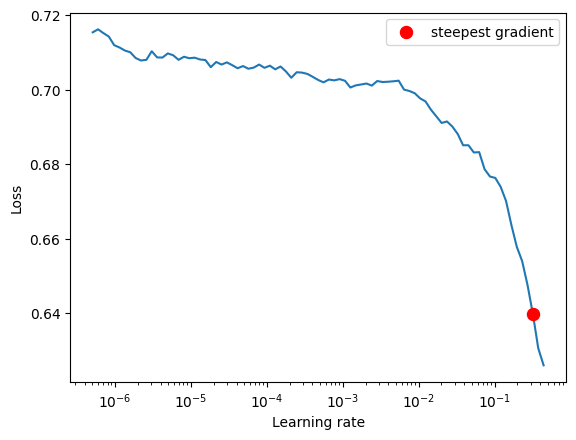

In [15]:
from torch_lr_finder import LRFinder

# Model, criterion, optimizer setup
criterion = torch.nn.BCEWithLogitsLoss()  # BCEWithLogitsLos for logits
optimizer = optim.SGD(efficientnet_model.parameters(), lr=1e-7)  # Learning rate
# Wrap with lr finder
lr_finder = LRFinder(efficientnet_model, optimizer, criterion, device="cpu")
lr_finder.range_test(train_loader, end_lr=1, num_iter=100)  # nummber of iteratioms
lr_finder.plot()  # plot loss vs learning rate
lr_finder.reset()
